In [1]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

In [3]:
from qrc_bloqade.encodings import amp_encode, angle_encode, global_encode,position_encode
from qrc_bloqade.hamiltonian import rydberg 
from qrc_bloqade.readouts import EnhancedReadout
from qrc_bloqade.solver import BloqadeSolver 
from qrc_bloqade.utils import(train_split, normalize, get_predictor, print_readout) 
from qrc_bloqade.samples import logistic_map_dataset,lorenz_dataset, analyze_chaos


In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

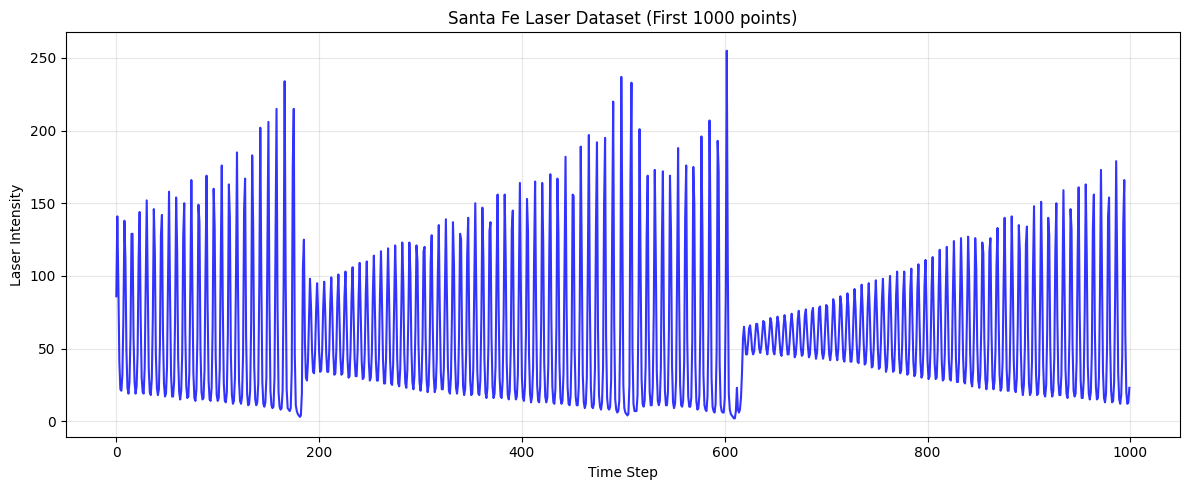

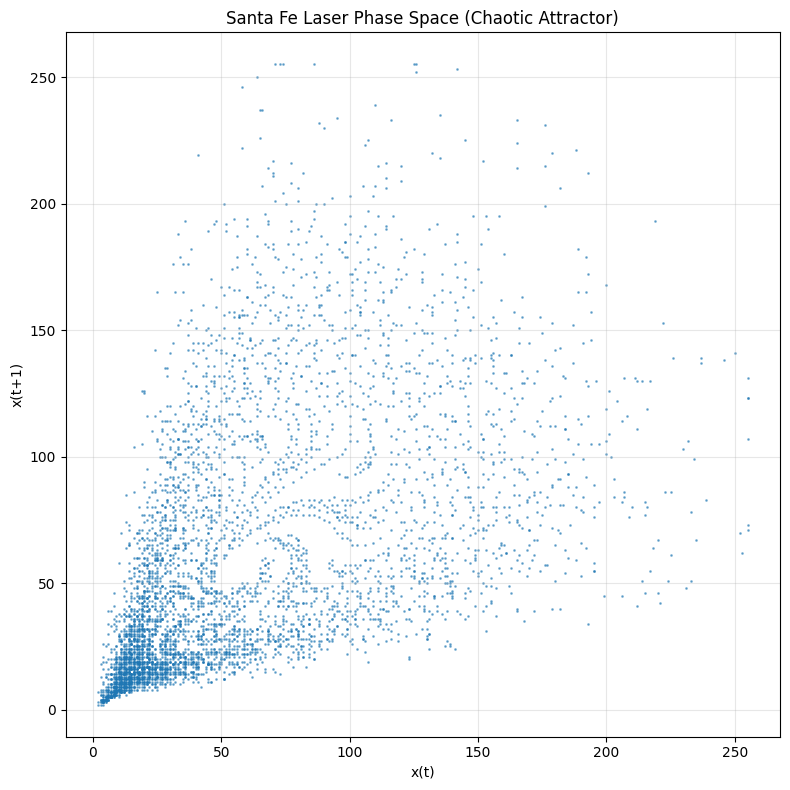

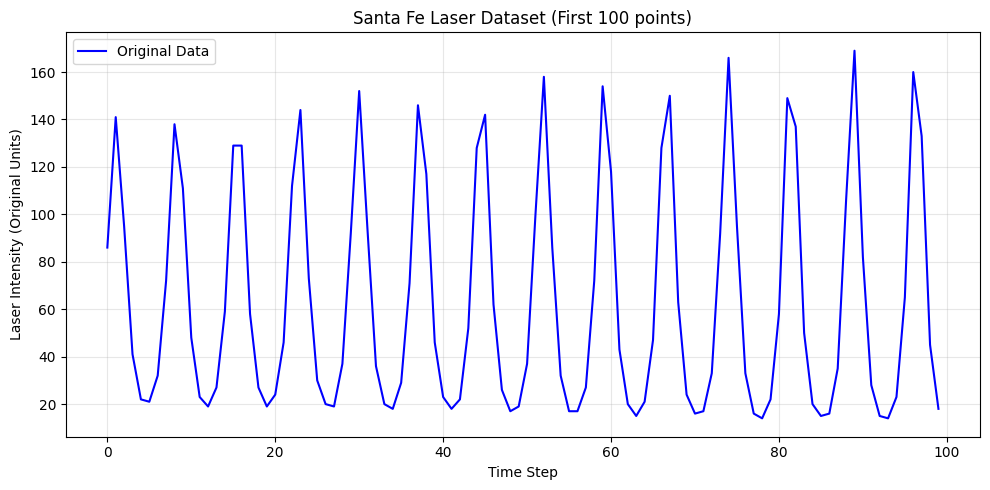

In [9]:
import matplotlib.pyplot as plt
from reservoirpy.datasets import santafe_laser
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split as train_split


def dataset_sf( n_features=4, n_ahead=1, train_size=0.6):
    data= santafe_laser()
    X,y=[],[]
    for i in range(len(data)-n_ahead-n_features+1):
        X.append(data[i:i+n_features])
        y.append(data[i+n_features+n_ahead-1])
    X=np.array(X)
    y=np.array(y).reshape(-1,1)
    print (f"Shape: {X.shape}, {y.shape}")
    X_norm , y_norm, scalar_X, scalar_y = normalize(X,y)

    X_train, y_train, X_test, y_test = train_split(X_norm, y_norm, test_size=1-train_size, random_state=402)
    #X_train, y_train = X_train.reshape(X_train.shape[0],-1), y_train.reshape(y_train.shape[0],-1)
    #X_test, y_test = X_test.reshape(X_test.shape[0],-1), y_test.reshape(y_test.shape[0],-1)
    return X_train, y_train, X_test, y_test, scalar_X, scalar_y

def visualize():
    data = santafe_laser()
    plt.figure(figsize=(12, 5))
    plt.plot(data[:1000], 'b-', alpha=0.8)
    plt.title('Santa Fe Laser Dataset (First 1000 points)')
    plt.xlabel('Time Step')
    plt.ylabel('Laser Intensity')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Also show the chaotic attractor
    plt.figure(figsize=(8, 8))
    plt.scatter(data[:-1][:5000], data[1:][:5000], s=1, alpha=0.5)
    plt.title('Santa Fe Laser Phase Space (Chaotic Attractor)')
    plt.xlabel('x(t)')
    plt.ylabel('x(t+1)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.figure(figsize=(10, 5))
    plt.plot(data[:100], 'b-', label='Original Data')
    plt.title('Santa Fe Laser Dataset (First 100 points)')
    plt.xlabel('Time Step')
    plt.ylabel('Laser Intensity (Original Units)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
   
    
visualize()

In [ ]:
def test_qrc():
    
    # Configuration parameters
    n_sites = 4
    time = 1.01
    base_omega = 1.12
    base_V = 1.12
    detuning_scale = 0.5
    
    print(f"DEBUG: Configuration - n_sites={n_sites}, time={time}, omega={base_omega}, V={base_V}")
    
    # Use global encoding with parameters from test function
    print("DEBUG: Creating encoder")
    encoder = global_encode(
        n_sites=n_sites,
        encoding_type='hamiltonian',
        base_omega=base_omega,
        base_V=base_V,
        detuning_scale=detuning_scale
    )
    
    print("DEBUG: Creating readout")
    readout = EnhancedReadout(n_sites, include_zz=True, include_multi_time=True, time_points=[50, 100, 150],  correlation_pairs=[(0,1), (1,2), (2,3)])
    print(f"DEBUG: Readout created with time_points={readout.time_points}, include_multi_time={readout.include_multi_time}")
    
    print("DEBUG: Creating predictors")
    predictor_qrc = get_predictor()
    predictor_rf = RandomForestRegressor(n_estimators=100, random_state=402)
    
    # Generate chaotic data
    print("DEBUG: Generating Lorenz dataset")
    X, y = lorenz_dataset(n_samples=500, n_features=n_sites)
    print(f"DEBUG: Dataset created with shape X:{X.shape}, y:{y.shape}")
    
    # Visualize dataset
    print("DEBUG: Analyzing chaos")
    analyze_chaos("Lorenz Attractor", lorenz_dataset, n_samples=500, n_features=n_sites)
    
    # Normalize data
    print("DEBUG: Normalizing data")
    X_normalized, y_normalized, scaler_X, scaler_y = normalize(X, y)
    
    # Split data
    print("DEBUG: Splitting data")
    X_train, X_val, X_test, y_train, y_val, y_test = train_split(
        X_normalized, y_normalized, test_size=0.4, random_state=402
    )
    print(f"DEBUG: Split sizes - Train:{X_train.shape}, Val+Test:{X_test.shape}")
    
    # Encode for QRC
    print("DEBUG: Encoding for QRC")
    encoded_states_train, hamiltonian_params_train = encoder.encode(X_train)
    encoded_states_test, hamiltonian_params_test = encoder.encode(X_test)
    print(f"DEBUG: Encoded states sizes - Train:{len(encoded_states_train)}, Test:{len(encoded_states_test)}")
    
    # Evolve with different Hamiltonians for each sample
    print("DEBUG: Creating solver")
    solver = BloqadeSolver()
    evolved_train = []
    evolved_test = []
    
    print("DEBUG: Evolving training states")
    for i, initial_state in enumerate(encoded_states_train):
        print(f"DEBUG: Evolving training sample {i+1}/{len(encoded_states_train)}")
        params = hamiltonian_params_train[i]
        hamiltonian = rydberg(
            n_sites=n_sites,
            omega=params['omega'],
            V=params['V'],
            detuning_values=params['detuning_values']
        )
        
        # Use return_all_steps=True to get states at all time steps
        result = solver.simulate_with_history(
            initial_state,
            hamiltonian=hamiltonian.construct_hamiltonian(),
            duration=time,
            steps=200,
            n_qubits=n_sites,
            return_history=True
          
        )
        evolved_train.append(result)
    
    print("DEBUG: Evolving test states")
    for i, initial_state in enumerate(encoded_states_test):
        print(f"DEBUG: Evolving test sample {i+1}/{len(encoded_states_test)}")
        params = hamiltonian_params_test[i]
        hamiltonian = rydberg(
            n_sites=n_sites,
            omega=params['omega'],
            V=params['V'],
            detuning_values=params['detuning_values']
        )
        
        # Use return_all_steps=True to get states at all time steps
        result = solver.simulate_with_history(
            initial_state,
            hamiltonian=hamiltonian.construct_hamiltonian(),
            duration=time,
            steps=200,
            n_qubits=n_sites,
            return_history=True
         
        )
        evolved_test.append(result)
    
    # Readout for QRC
    print("DEBUG: Measuring QRC features")
    print(f"DEBUG: Type of first evolved_train element: {type(evolved_train[0])}")
    print(f"DEBUG: Length of first evolved_train element: {len(evolved_train[0])}")
    train_features_qrc = readout.measure(evolved_train, n_sites)
    test_features_qrc = readout.measure(evolved_test, n_sites)
    print(f"DEBUG: Feature shapes - Train:{train_features_qrc.shape}, Test:{test_features_qrc.shape}")
    
    # Train QRC predictor
    print("DEBUG: Training QRC predictor")
    predictor_qrc.fit(train_features_qrc, y_train)
    predictions_qrc = predictor_qrc.predict(test_features_qrc)
    
    # Train Classical RandomForest
    print("DEBUG: Training Random Forest predictor")
    predictor_rf.fit(X_train, y_train)
    predictions_rf = predictor_rf.predict(X_test)
    
    # Inverse transform to get original scale
    print("DEBUG: Inverse transforming predictions")
    predictions_qrc = scaler_y.inverse_transform(predictions_qrc.reshape(-1, 1)).flatten()
    predictions_rf = scaler_y.inverse_transform(predictions_rf.reshape(-1, 1)).flatten()
    y_test = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
    
    # Compute MSE
    print("DEBUG: Computing MSE")
    mse_qrc = mean_squared_error(y_test, predictions_qrc)
    mse_rf = mean_squared_error(y_test, predictions_rf)
    
    print(f"Test MSE (Quantum Reservoir Computing): {mse_qrc}")
    print(f"Test MSE (Random Forest): {mse_rf}")


Running test Encoding Test...
DEBUG: Starting test_qrc_vs_classical function
DEBUG: Configuration - n_sites=4, time=1.01, omega=1.12, V=1.12
DEBUG: Creating encoder
DEBUG: Creating readout
DEBUG: Readout created with time_points=[50, 100, 150], include_multi_time=True
DEBUG: Creating predictors
DEBUG: Generating Lorenz dataset
DEBUG: Dataset created with shape X:(500, 4), y:(500,)
DEBUG: Analyzing chaos


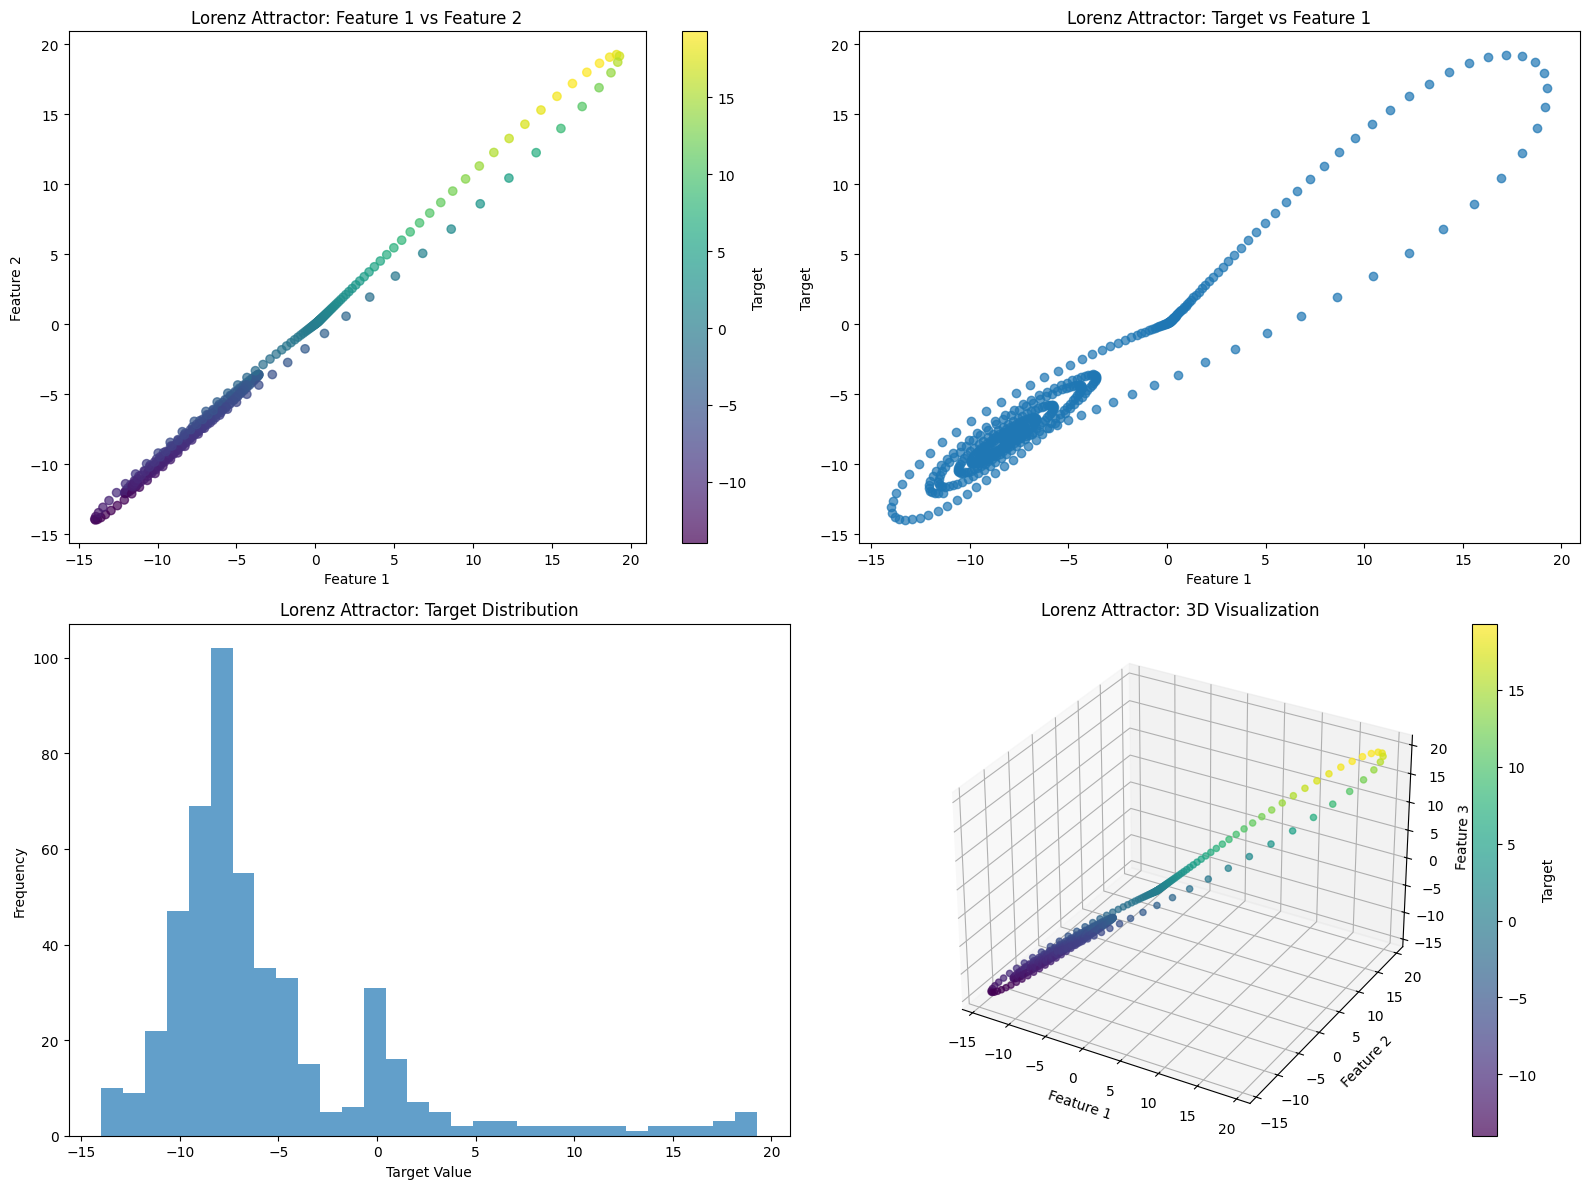


=== Lorenz Attractor Dataset Analysis ===
Shape: (500, 4), (500,)
Feature range: [-13.9832, 19.2761]
Target range: [-13.9832, 19.2761]

Feature Correlation Matrix:
[[1.         0.99807728 0.99233253 0.98284514]
 [0.99807728 1.         0.9980729  0.99231307]
 [0.99233253 0.9980729  1.         0.9980675 ]
 [0.98284514 0.99231307 0.9980675  1.        ]]

Feature-Target Correlations:
[0.96975111 0.98279735 0.99228967 0.99806115]


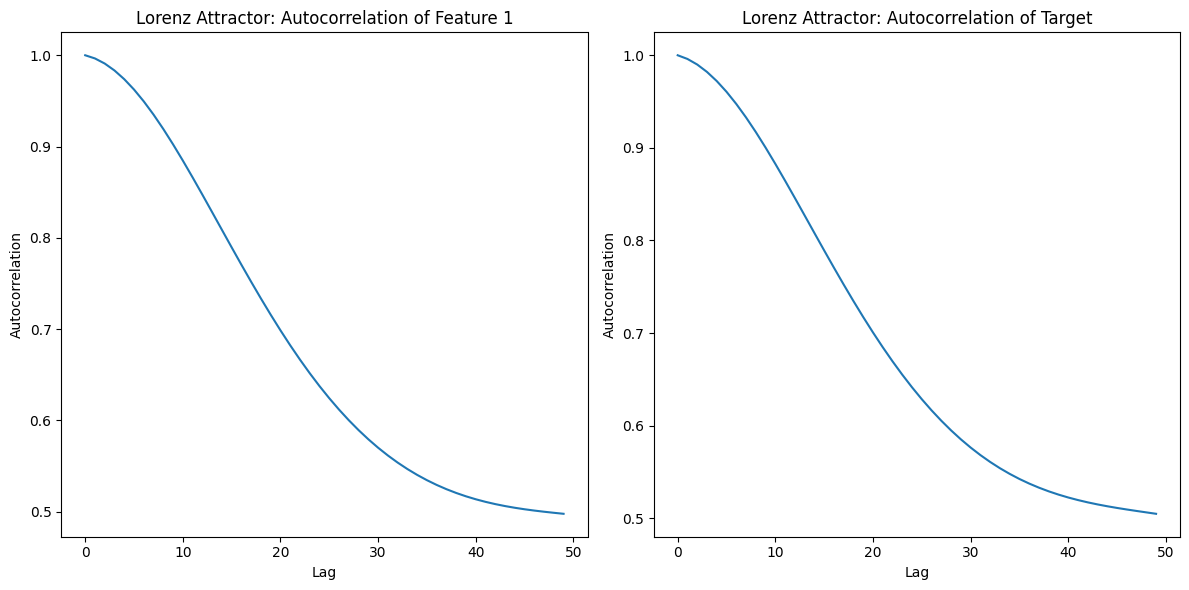

DEBUG: Normalizing data
DEBUG: Splitting data
DEBUG: Split sizes - Train:(300, 4), Val+Test:(100, 4)
DEBUG: Encoding for QRC
DEBUG: Encoded states sizes - Train:300, Test:100
DEBUG: Creating solver
DEBUG: Evolving training states
DEBUG: Evolving training sample 1/300
DEBUG: Evolving training sample 2/300
DEBUG: Evolving training sample 3/300
DEBUG: Evolving training sample 4/300
DEBUG: Evolving training sample 5/300
DEBUG: Evolving training sample 6/300
DEBUG: Evolving training sample 7/300
DEBUG: Evolving training sample 8/300
DEBUG: Evolving training sample 9/300
DEBUG: Evolving training sample 10/300
DEBUG: Evolving training sample 11/300
DEBUG: Evolving training sample 12/300
DEBUG: Evolving training sample 13/300
DEBUG: Evolving training sample 14/300
DEBUG: Evolving training sample 15/300
DEBUG: Evolving training sample 16/300
DEBUG: Evolving training sample 17/300
DEBUG: Evolving training sample 18/300
DEBUG: Evolving training sample 19/300
DEBUG: Evolving training sample 20/300

In [ ]:
if __name__ == "__main__":
 print("\nRunning test Encoding Test...")
 test_qrc()